#### Book to TXT

In [ ]:
####

In [5]:
import pdfplumber
import string

def pdf_to_txt(pdf_path, txt_path):
    """
    Extracts text from a PDF file and writes each word to a new line in a TXT file.
    
    :param pdf_path: Path to the input PDF file.
    :param txt_path: Path to the output TXT file.
    """
    with pdfplumber.open(pdf_path) as pdf, open(txt_path, 'w', encoding='utf-8') as txt_file:
        for page in pdf.pages:
            words = page.extract_text().split()
            for word in words:
                clean_word = word.translate(str.maketrans("", "",string.punctuation))
                txt_file.write(word + "\n")



In [6]:

pdf_to_txt("/home/akash/ws/limited_supervision_ocr/synthetic_data_gen/vocabulary/book/the_guide.pdf", "output.txt")

#### Download wikipedia words

In [ ]:
%%capture

! wikiextractor enwiki-latest-pages-articles.xml.bz2 -o extracted_text


In [7]:
# import os
# import string

# def extract_words_to_txt(input_dir, output_file, word_limit=600):
#     num_words = 0
#     with open(output_file, 'w', encoding='utf-8') as txt_file:
#         for root, _, files in os.walk(input_dir):
#             for file in files:
#                 with open(os.path.join(root, file), 'r', encoding='utf-8') as f:
#                     for line in f:
#                         words = line.split()
#                         for word in words:
#                             # Remove punctuation and trim spaces
#                             clean_word = word.translate(str.maketrans('', '', string.punctuation)).strip()
                            
#                             # Skip words containing unwanted substrings
#                             if any(sub in clean_word.lower() for sub in ["http", "https", "www", "url", "<", ">", "id", "doc", '">']):
#                                 continue

#                             # Write only words that contain alphabetic characters exclusively
#                             if clean_word and clean_word.isalpha() and clean_word.isascii():
#                                 txt_file.write(clean_word + "\n")
#                                 num_words += 1
#                                 print(f"Number of words added: {num_words}")
                                
#                                 if num_words >= word_limit:
#                                     return


import os
import re
import string

def extract_words_to_txt(input_dir, output_file, word_limit=600):
    num_words = 0
    # This regex splits text into word parts (alphabetic sequences) and punctuation characters.
    token_pattern = re.compile(r"[A-Za-z]+|[" + re.escape(string.punctuation) + "]")
    
    with open(output_file, 'w', encoding='utf-8') as txt_file:
        for root, _, files in os.walk(input_dir):
            for file in files:
                file_path = os.path.join(root, file)
                with open(file_path, 'r', encoding='utf-8') as f:
                    for line in f:
                        tokens = token_pattern.findall(line)
                        # Reconstruct tokens such that punctuation immediately following a word is appended.
                        processed_tokens = []
                        for token in tokens:
                            if token.isalpha():
                                # A word token is added as a new token.
                                processed_tokens.append(token)
                            else:
                                # For punctuation tokens:
                                if processed_tokens:
                                    # Append the punctuation to the previous token.
                                    processed_tokens[-1] += token
                                else:
                                    # If there is no preceding word, output punctuation as its own token.
                                    processed_tokens.append(token)
                        
                        # Process each token applying the unwanted substring filter.
                        for token in processed_tokens:
                            # Remove trailing punctuation for filtering purposes.
                            base_word = token.rstrip(string.punctuation)
                            
                            if any(sub in base_word.lower() for sub in ["http", "https", "www", "url", "<", ">", "id", "doc", '">']):
                                continue
                            
                            # Validate that the base word (if any) is alphabetic and in ASCII.
                            if base_word and base_word.isalpha() and base_word.isascii():
                                txt_file.write(token + "\n")
                                num_words += 1
                                print(f"Number of words added: {num_words}")
                                
                                if num_words >= word_limit:
                                    return


In [8]:
%%capture
# Example Usage
extract_words_to_txt("extracted_text", "wikipedia_words.txt", 6000000)

#### Analysis

In [9]:
import string
import matplotlib.pyplot as plt
from collections import Counter

def analyze_txt_file(txt_path, output_report):
    """
    Performs a detailed analysis of a text file containing words for OCR training and generates plots.
    
    :param txt_path: Path to the input TXT file containing words.
    :param output_report: Path to save the detailed analysis report.
    """
    words = []
    char_counter = Counter()
    
    with open(txt_path, 'r', encoding='utf-8') as file:
        for line in file:
            word = line.strip()
            if word:
                words.append(word)
                char_counter.update(word)
    
    total_words = len(words)
    unique_words = set(words)
    word_frequencies = Counter(words)
    
    avg_word_length = sum(len(word) for word in words) / total_words if total_words > 0 else 0
    most_common_words = word_frequencies.most_common(10)
    least_common_words = word_frequencies.most_common()[-10:]
    
    digit_count = sum(1 for word in words if any(char.isdigit() for char in word))
    special_char_words = sum(1 for word in words if any(char in string.punctuation for char in word))
    
    with open(output_report, 'w', encoding='utf-8') as report:
        report.write(f"Total Words: {total_words}\n")
        report.write(f"Unique Words: {len(unique_words)}\n")
        report.write(f"Average Word Length: {avg_word_length:.2f}\n")
        report.write(f"Words Containing Digits: {digit_count}\n")
        report.write(f"Words Containing Special Characters: {special_char_words}\n")
        report.write("\nMost Common Words:\n")
        for word, count in most_common_words:
            report.write(f"{word}: {count}\n")
        
        report.write("\nLeast Common Words:\n")
        for word, count in least_common_words:
            report.write(f"{word}: {count}\n")
        
        report.write("\nCharacter Frequency:\n")
        for char, count in char_counter.most_common():
            report.write(f"{char}: {count}\n")
    
    print(f"Analysis report saved to {output_report}")
    
    # Generate plots
    plt.figure(figsize=(10, 5))
    plt.bar(*zip(*most_common_words))
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.title("Top 10 Most Common Words")
    plt.xticks(rotation=45)
    plt.savefig("most_common_words.png")
    plt.show()
    
    plt.figure(figsize=(10, 5))
    plt.bar(*zip(*char_counter.most_common(10)))
    plt.xlabel("Characters")
    plt.ylabel("Frequency")
    plt.title("Top 10 Most Common Characters")
    plt.savefig("char_frequency.png")
    plt.show()




Analysis report saved to ocr_analysis_report.txt


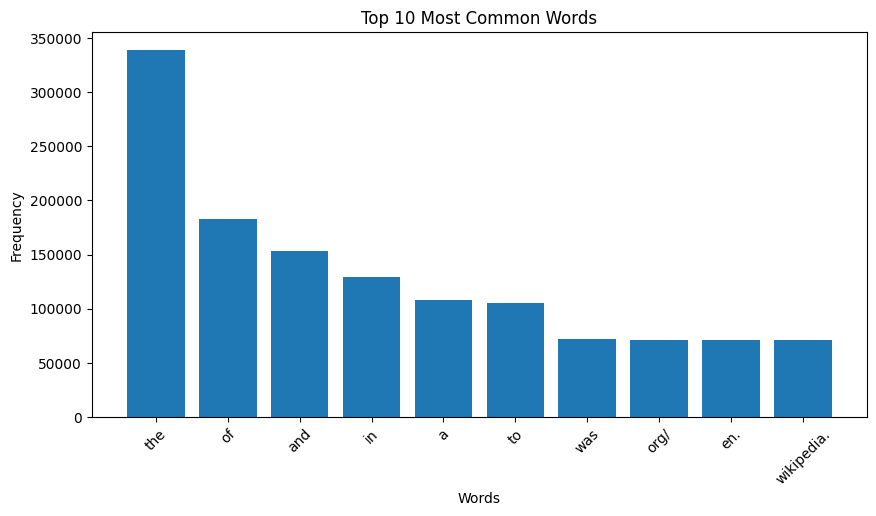

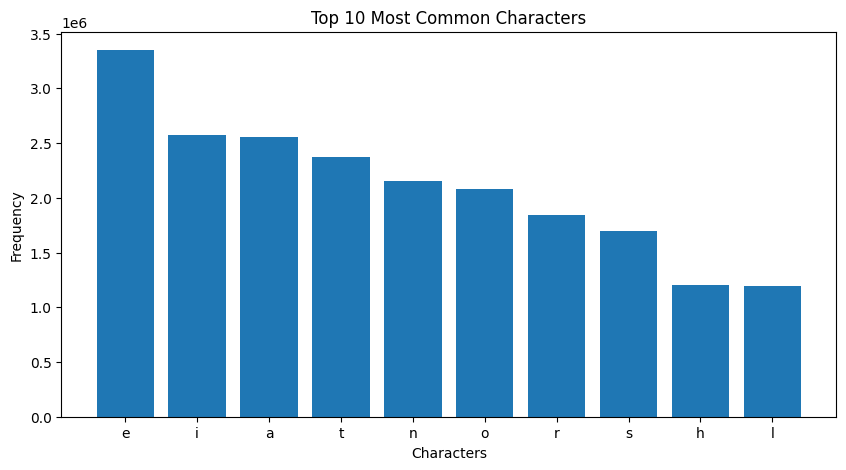

In [10]:
analyze_txt_file("/home/akash/ws/limited_supervision_ocr/synthetic_data_gen/vocabulary/book/wikipedia_words.txt", "ocr_analysis_report.txt")

#### Split data into train and val

In [11]:
import argparse
import random

def split_data(input_file, train_file, val_file, val_ratio=0.2, seed=42):
    # Read all words from the input file, stripping any whitespace.
    with open(input_file, 'r', encoding='utf-8') as f:
        words = [line.strip() for line in f if line.strip()]
    
    # Shuffle the list of words to ensure random distribution.
    random.seed(seed)
    random.shuffle(words)
    
    # Compute the index at which to split the list based on the validation ratio.
    split_index = int(len(words) * (1 - val_ratio))
    
    # Split into training and validation sets.
    train_words = words[:split_index]
    val_words = words[split_index:]
    
    # Write the training words to the train_file.
    with open(train_file, 'w', encoding='utf-8') as f:
        f.write("\n".join(train_words))
    
    # Write the validation words to the val_file.
    with open(val_file, 'w', encoding='utf-8') as f:
        f.write("\n".join(val_words))
    
    print(f"Total words: {len(words)}")
    print(f"Training words: {len(train_words)}")
    print(f"Validation words: {len(val_words)}")


    
    


In [12]:

input_file = "/home/akash/ws/limited_supervision_ocr/synthetic_data_gen/vocabulary/book/wikipedia_words.txt"
train_file = "/home/akash/ws/limited_supervision_ocr/synthetic_data_gen/vocabulary/book/train_wikipedia_words.txt"
val_file = "/home/akash/ws/limited_supervision_ocr/synthetic_data_gen/vocabulary/book/val_wikipedia_words.txt"
val_ratio = 0.01
seed = 42
split_data(input_file, train_file, val_file, val_ratio, seed)

Total words: 6000000
Training words: 5940000
Validation words: 60000


#### cleaning

In [2]:
! pip install nltk

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)
Using cached click-8.1.8-py3-none-any.whl (98 kB)


In [5]:
import sys
import string
import nltk
from nltk.corpus import words

# Download the NLTK words corpus if it's not already available.
nltk.download('words', quiet=True)
english_vocab = set(word.lower() for word in words.words())

def process_line(line):
    # Remove punctuation using str.translate.
    translator = str.maketrans("", "", string.punctuation)
    line_no_punct = line.translate(translator)
    
    # Tokenize the line into words (using whitespace split).
    tokens = line_no_punct.split()
    
    # Filter out tokens not present in the English vocabulary.
    filtered_tokens = [word for word in tokens if word.lower() in english_vocab]
    
    # Return the cleaned line.
    return " ".join(filtered_tokens)

def main(input_file, output_file):
    with open(input_file, 'r', encoding='utf-8') as fin, open(output_file, 'w', encoding='utf-8') as fout:
        for line in fin:
            cleaned_line = process_line(line)
            # Only write non-empty cleaned lines
            if cleaned_line.strip():
                fout.write(cleaned_line + "\n")

if __name__ == '__main__':
    input_file = "/home/akash/ws/limited_supervision_ocr/synthetic_data_gen/vocabulary/book/train_wikipedia_words.txt"
    output_file = "/home/akash/ws/limited_supervision_ocr/synthetic_data_gen/vocabulary/book/punc_removestrain_wikipedia_words.txt"
    main(input_file, output_file)

